<a href="https://colab.research.google.com/github/hanshunyi0-cyber/bank_marketing/blob/main/website/public/modules/python-ai-engineering/challenges/aie-s2-bank-marketing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIE S2 — Bank Term Deposit

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/racousin/data_science_practice/blob/main/website/public/modules/python-ai-engineering/challenges/aie-s2-bank-marketing.ipynb)

**Classification.** A Portuguese bank ran a direct marketing
campaign: 45,211 calls, and for each one, whether the client
subscribed a term deposit afterwards. Predict that outcome for calls
you have not been shown.

Challenge: <https://ml-arena.com/viewchallenge/184>

---

**This notebook contains no code, and that is deliberate.** You have
just read the bike-demand notebook, which is the same five steps on a
regression target. Here the steps are written and the
cells are empty. Write them yourself.

Two things genuinely differ from the bike challenge, and both are
flagged below where they bite: the target is a **class**, not a
quantity, and it is **imbalanced** — only 11.7% of clients said yes.

---

## 0. Setup

Install the ML-Arena client. `pandas`, `seaborn` and `scikit-learn`
are already available in Colab.

The distribution is **`mlarena-sdk`** and it imports as `mlarena`.
`pip install mlarena`

In [2]:
!pip install -q mlarena-sdk

---

## 1. Get the data

Connect with your personal `mlk_user_...` key from your ML-Arena
Profile page, and download the dataset for challenge **184**
into the working directory. Same two calls as last time.

In [3]:
import mlarena

API_KEY = "mlk_user_9ce77dfbc86d8066_32b901e2aac1d3c7339edcff9a8235a2"
CHALLENGE_ID = 184
client = mlarena.connect(api_key=API_KEY)
client.download_dataset(CHALLENGE_ID,".")

['./X_train.csv', './X_test.csv', './y_train.csv']

---

## 2. Read it

Load `X_train.csv`, the `prediction` column of `y_train.csv`, and
`X_test.csv`.

Then answer three questions before going further:

- What are **n** and **p**?
- Which columns are numeric and which are text?
- **What fraction of the training target is 1?** Compute it now. This
  number decides your metric and your reading of every result that
  follows.

In [4]:
import pandas as pd
X_train=pd.read_csv("X_train.csv")
y_train=pd.read_csv("y_train.csv")["prediction"]
X_test=pd.read_csv("X_test.csv")
print("X_train",X_train.shape)
print("y_train",y_train.shape)
print("X_test",X_test.shape)

print(y_train.value_counts())

X_train (36168, 17)
y_train (36168,)
X_test (9043, 17)
prediction
0    31937
1     4231
Name: count, dtype: int64


In [23]:
X_train.dtypes

,0
id,object
age,int64
job,object
marital,object
education,object
default,object
balance,int64
housing,object
loan,object
contact,object


---

## 3. Look at it

Aim for five or six plots. For each one, ask what decision it changes.

**3a. The target.** Count the two classes. Confirm the imbalance you
computed above, and work out what accuracy you would get by always
predicting the majority class. Write that number down; it is the
number your model has to be judged against.

**3b. A numeric feature against the target.** Compare the
distribution of `duration` (call length in seconds) for clients who
subscribed and clients who did not. A boxplot or a pair of histograms
will do. The separation is large — then read the note in step 4 about
why that should make you uneasy rather than pleased.

**3c. A categorical feature against the target.** Plot the
**subscription rate** — not the raw count — per level of `poutcome`
(the outcome of the previous campaign), `month`, and `job`. Raw counts
will mostly tell you which levels are common; the rate is what tells
you which are predictive. `groupby(col)[target].mean()` gives it to
you directly.

**3d. Age.** Plot the subscription rate against age in bins. It is not
monotone. Note what that means for a model that multiplies age by a
single coefficient.

**3e. Two more columns that look like quantities.** Do the same rate
plot for `day` (day of the month, 1-31) and for `duration` cut into
deciles — 3b showed you `duration`'s distribution, this is its rate.
Neither one climbs in a straight line. Write down, for each, the
single sentence a lone coefficient would be forced to say about it;
with your age plot from 3d that is three notes you will need in
step 7.

**3f. Correlation.** Heatmap the numeric columns. Check whether any
pair is nearly redundant.

**3g. `pdays`.** Look at its distribution. The value `-1` is a flag
meaning "never previously contacted", not a quantity — so the column
mixes a category and a measurement in one place. Decide what to do
about it, and be able to say why.

In [8]:
df = X_train.assign(prediction=y_train)
df.head(3)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,prediction
0,tr_8b4549bd884a,35,services,married,secondary,no,44,yes,no,telephone,17,apr,377,2,-1,0,unknown,0
1,tr_5c0f32a83c1f,41,blue-collar,married,primary,no,402,no,no,unknown,17,jun,114,17,-1,0,unknown,0
2,tr_2513d28bb205,39,services,married,secondary,no,-404,yes,no,cellular,11,may,344,1,-1,0,unknown,0


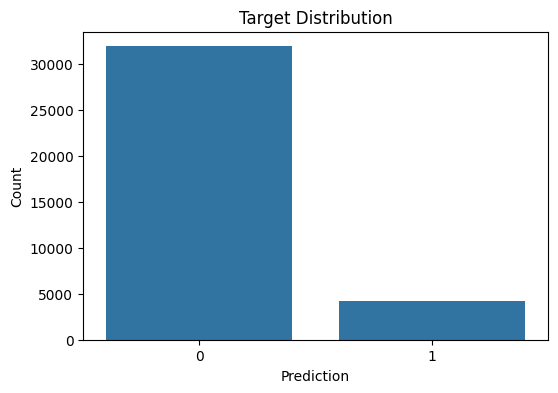

Positive rate: 0.1170
Always predict 0 accuracy: 0.8830


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="prediction")
plt.title("Target Distribution")
plt.xlabel("Prediction")
plt.ylabel("Count")
plt.show()

positive_rate = df["prediction"].mean()
baseline_accuracy = (df["prediction"] == 0).mean()

print(f"Positive rate: {positive_rate:.4f}")
print(f"Always predict 0 accuracy: {baseline_accuracy:.4f}")

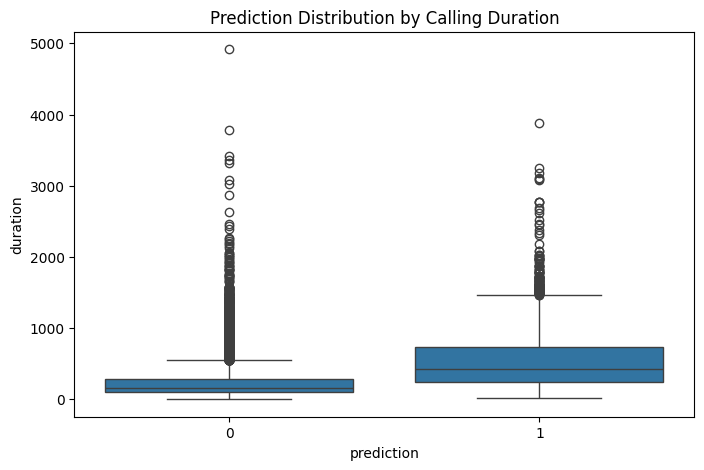

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x="prediction", y="duration",ax=ax)
ax.set_title("Prediction Distribution by Calling Duration")
plt.show()

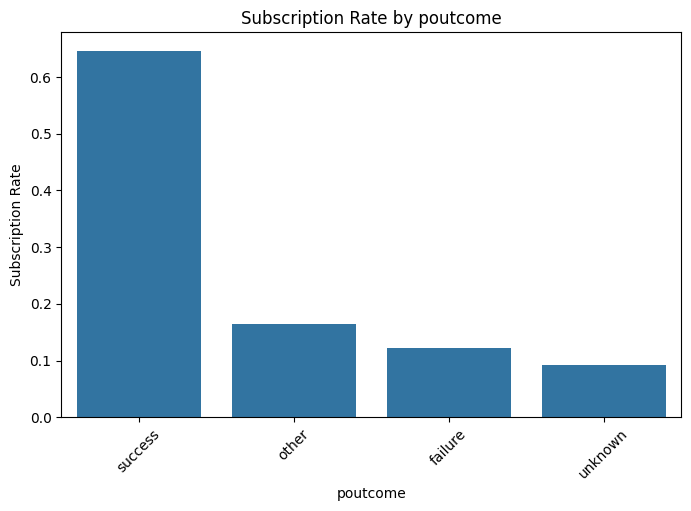

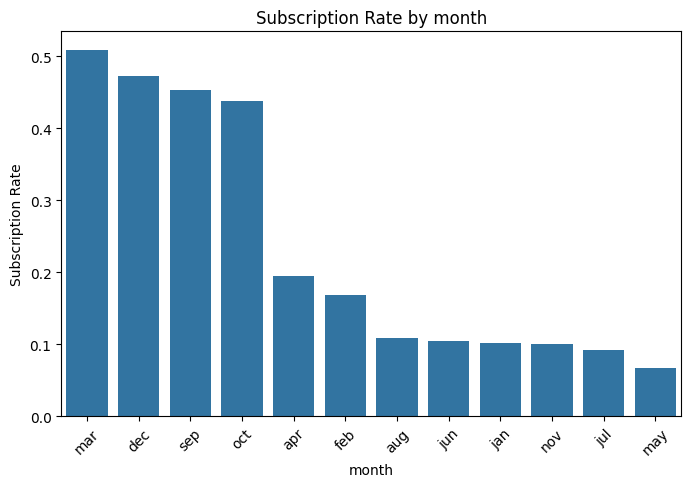

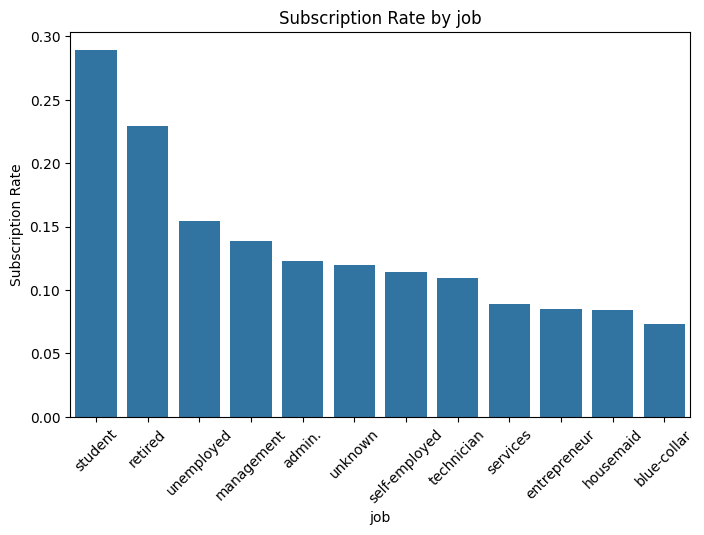

In [15]:
for col in ["poutcome", "month", "job"]:
    rate = df.groupby(col)["prediction"].mean().sort_values(ascending=False)

    fig,ax=plt.subplots(figsize=(8, 5))
    sns.barplot(x=rate.index,y=rate.values,ax=ax)
    ax.set_title(f"Subscription Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Subscription Rate")
    plt.xticks(rotation=45)
    plt.show()

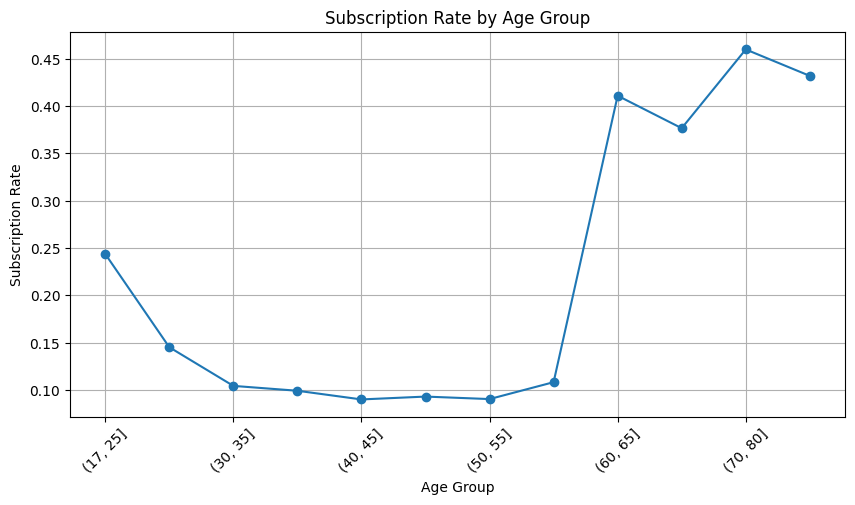

In [16]:
df["age_bin"] = pd.cut(
    df["age"],
    bins=[17, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 80, 100]
)

age_rate = df.groupby("age_bin", observed=True)["prediction"].mean()

plt.figure(figsize=(10, 5))
age_rate.plot(marker="o")
plt.title("Subscription Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

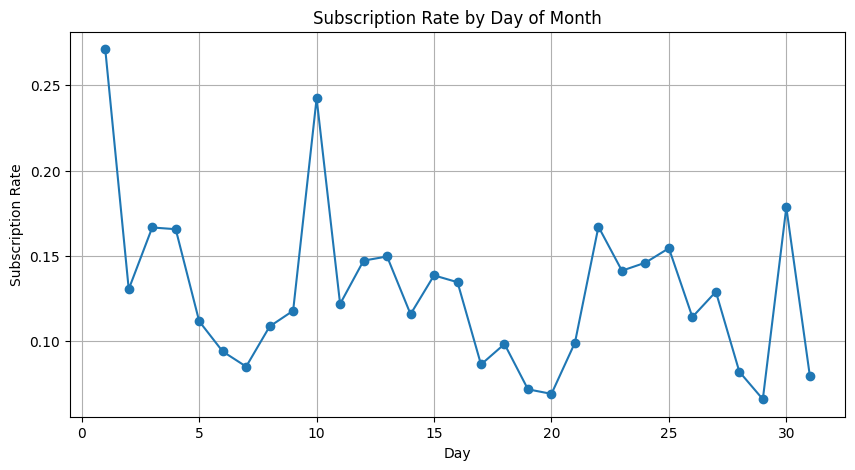

In [17]:
day_rate = df.groupby("day")["prediction"].mean()

plt.figure(figsize=(10, 5))
day_rate.plot(marker="o")
plt.title("Subscription Rate by Day of Month")
plt.xlabel("Day")
plt.ylabel("Subscription Rate")
plt.grid(True)
plt.show()

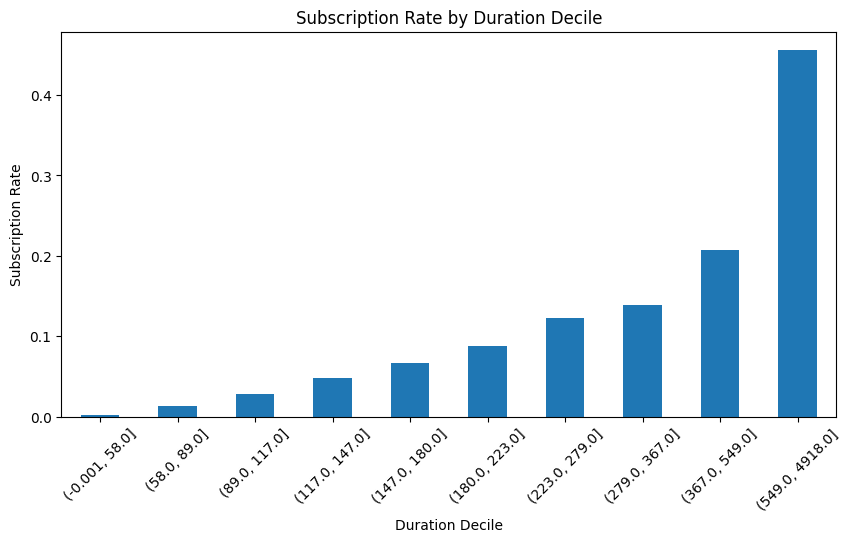

In [18]:
df["duration_decile"] = pd.qcut(
    df["duration"],
    q=10,
    duplicates="drop"
)

duration_rate = (
    df.groupby("duration_decile", observed=True)["prediction"]
    .mean()
)

plt.figure(figsize=(10, 5))
duration_rate.plot(kind="bar")
plt.title("Subscription Rate by Duration Decile")
plt.xlabel("Duration Decile")
plt.ylabel("Subscription Rate")
plt.xticks(rotation=45)
plt.show()

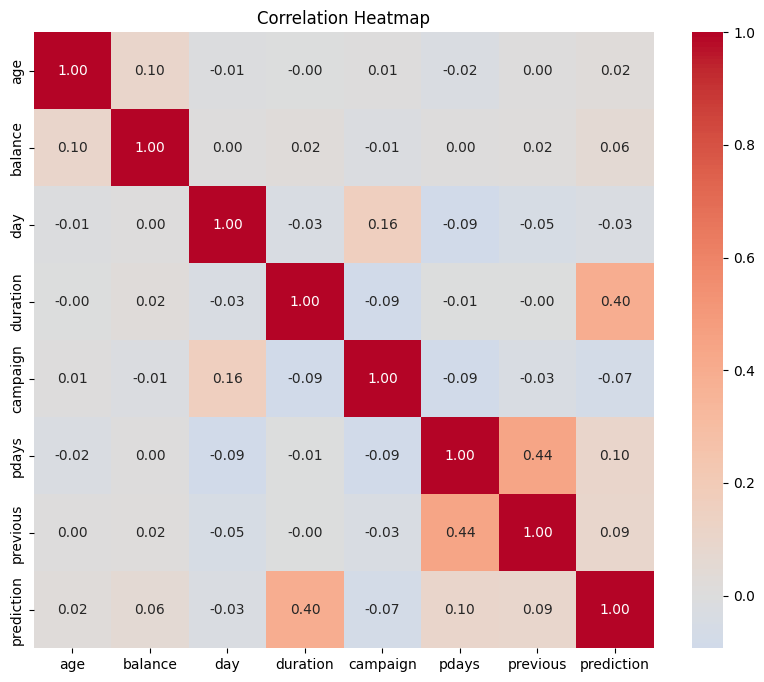

In [19]:
numeric_cols = df.select_dtypes(include="number").columns

plt.figure(figsize=(10, 8))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.show()

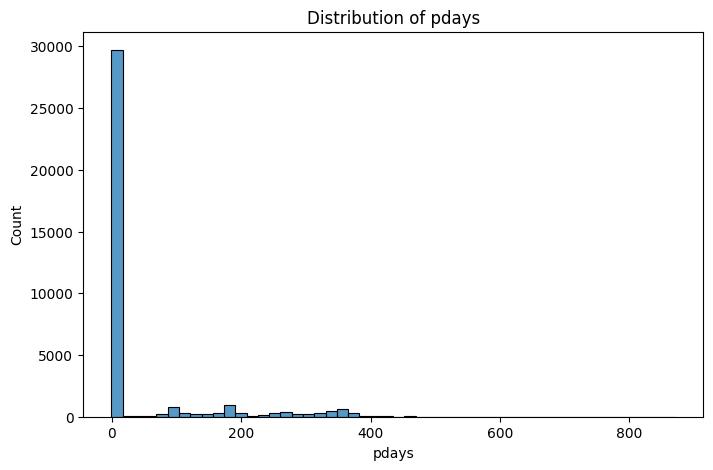

pdays == -1: 29584
poutcome == unknown: 29589
previous == 0: 29584
pdays == -1 and poutcome == unknown: 29584
pdays == -1 and previous == 0: 29584


In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="pdays",
    bins=50
)

plt.title("Distribution of pdays")
plt.xlabel("pdays")
plt.ylabel("Count")
plt.show()

print("pdays == -1:", (df["pdays"] == -1).sum())
print("poutcome == unknown:", (df["poutcome"] == "unknown").sum())
print("previous == 0:", (df["previous"] == 0).sum())

print(
    "pdays == -1 and poutcome == unknown:",
    ((df["pdays"] == -1) & (df["poutcome"] == "unknown")).sum()
)

print(
    "pdays == -1 and previous == 0:",
    ((df["pdays"] == -1) & (df["previous"] == 0)).sum()
)

---

## 4. Turn it into numbers

Same problem as before: nine of the sixteen columns are text. One-hot
encode them, and align the test columns to the training ones — an
encoding done independently on the two frames will not match.

**Then scale the numeric columns.** This is the step the bike notebook
did not need. `balance` runs from −8,019 to 102,127 while `campaign`
runs from 1 to 63; the solver behind `LogisticRegression` will not
converge in a sensible number of iterations if you hand it both
untouched. `StandardScaler` fitted on the training matrix is enough.

**A decision to make here.** `duration` is the length of the call you
are predicting the outcome of. You only know it once the call has
ended — so a model that relies on it could never run *before* placing
the call. It is in the data and you may use it. Decide whether you
want to, and say why in a comment. Both answers are defensible; an
unexamined answer is not.

In [21]:
from sklearn.preprocessing import StandardScaler
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Keep IDs separately
train_ids = X_train_raw["id"].copy()
test_ids = X_test_raw["id"].copy()

# ID is not a predictive feature
X_train_raw = X_train_raw.drop(columns=["id"])
X_test_raw = X_test_raw.drop(columns=["id"])

In [25]:
"""
Decision: Keep duration because this challenge explicitly allows using it. In a real pre-call deployment setting, duration would be unavailable.
"""

categorical_cols = X_train_raw.select_dtypes(
    include=["object","category"]
).columns.tolist()

numeric_cols = X_train_raw.select_dtypes(
    include=["number"]
).columns.tolist()

print("Categorical columns:")
print(categorical_cols)

print("\nNumeric columns:")
print(numeric_cols)

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

Numeric columns:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


In [26]:
# One-hot encode train and test together so that
# both matrices have exactly the same columns.
X_all = pd.concat(
    [X_train_raw, X_test_raw],
    axis=0
)

X_all_encoded = pd.get_dummies(
    X_all,
    columns=categorical_cols,
    drop_first=False,
    dtype=float
)

# Split them back
X_train_encoded = X_all_encoded.iloc[:len(X_train_raw)].copy()
X_test_encoded = X_all_encoded.iloc[len(X_train_raw):].copy()

# Scale numeric columns
scaler = StandardScaler()

X_train_encoded[numeric_cols] = scaler.fit_transform(
    X_train_encoded[numeric_cols]
)

X_test_encoded[numeric_cols] = scaler.transform(
    X_test_encoded[numeric_cols]
)

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

print(
    "Columns aligned:",
    list(X_train_encoded.columns) == list(X_test_encoded.columns)
)

Encoded train shape: (36168, 51)
Encoded test shape: (9043, 51)
Columns aligned: True


---

## 5. Fit it and read the numbers

Fit `LogisticRegression` on the training matrix and score it on those
same rows. As in the bike notebook, that is deliberate: this session
measures the fit on the data it was fitted to, which a model with one
coefficient per column can be trusted to answer honestly. Session 3 is
where you learn to measure it properly.

Report **four** numbers: accuracy, precision, recall and F1. Then:

- Compare your accuracy with the always-predict-0 accuracy from step
  3a. If they are close, your accuracy is telling you nothing.
- Look at precision against recall. A model that almost never predicts
  1 will have decent precision and terrible recall, and F1 is the
  number that refuses to let you ignore that.
- A confusion matrix makes all four legible at once. Plot it.

The challenge ranks on **F1 on the positive class**, for exactly the
reason step 3a made visible.

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model.fit(
    X_train_encoded,
    y_train
)

y_pred = model.predict(X_train_encoded)

accuracy = accuracy_score(y_train, y_pred)
precision = precision_score(y_train, y_pred)
recall = recall_score(y_train, y_pred)
f1 = f1_score(y_train, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1       : {f1:.4f}")

print(
    f"\nMajority-class baseline accuracy: "
    f"{baseline_accuracy:.4f}"
)

Accuracy : 0.9020
Precision: 0.6538
Recall   : 0.3451
F1       : 0.4517

Majority-class baseline accuracy: 0.8830


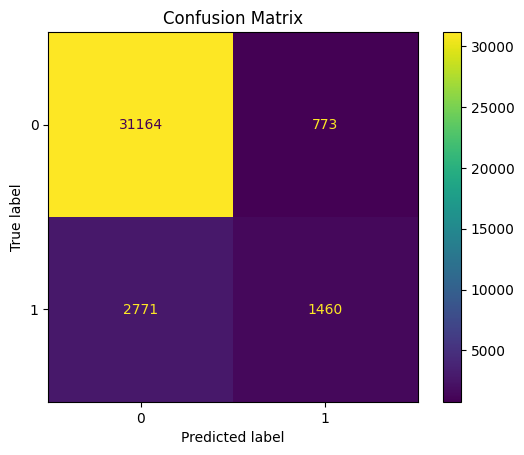

In [55]:
cm = confusion_matrix(y_train, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[0, 1]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

---

## 6. The threshold is yours

`predict()` labels a client as 1 when the predicted probability
exceeds 0.5. That 0.5 is a convention, not a property of the problem,
and on a target that is 11.7% positive it is rarely the best choice.

Use `predict_proba()` to get the probabilities, then:

- Sweep the threshold from 0.05 to 0.60 and plot F1 against it.
- Read off the best one and keep it.

On this dataset the move is worth more than changing model family —
it is worth about **0.13 of F1**, and no model in Session 3 will buy
you that. Sweep it here, in the notebook; the leaderboard gives you
one number per submission and is not a search space.

Best threshold: 0.205
Best F1: 0.5781


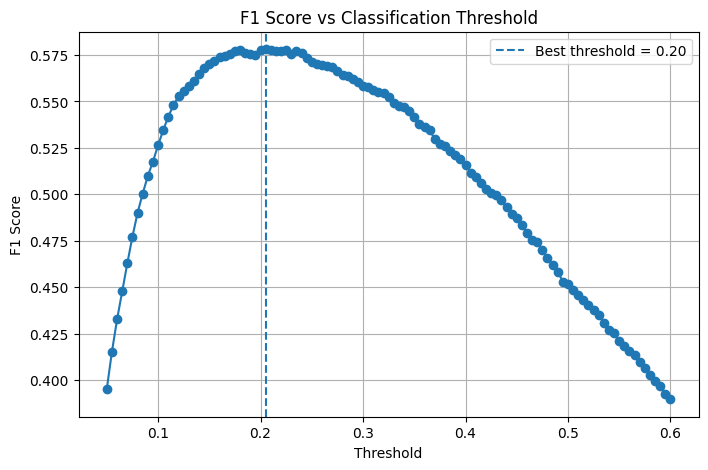

In [86]:
from sklearn.metrics import f1_score

# Predicted probability of positive class
y_prob = model.predict_proba(X_train_encoded)[:, 1]

thresholds = [
    round(t, 5)
    for t in
    __import__("numpy").arange(0.05, 0.601, 0.005)
]

f1_scores = []

for threshold in thresholds:
    y_threshold = (y_prob >= threshold).astype(int)

    score = f1_score(
        y_train,
        y_threshold
    )

    f1_scores.append(score)

best_idx = __import__("numpy").argmax(f1_scores)

best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Best threshold: {best_threshold:.3f}")
print(f"Best F1: {best_f1:.4f}")

plt.figure(figsize=(8, 5))

plt.plot(
    thresholds,
    f1_scores,
    marker="o"
)

plt.axvline(
    best_threshold,
    linestyle="--",
    label=f"Best threshold = {best_threshold:.2f}"
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Classification Threshold")
plt.legend()
plt.grid(True)
plt.show()

---

## 7. Go further: put the shapes you saw into the columns

The threshold was the cheap move and you have spent it. What is left
is the move the model cannot make for itself.

`LogisticRegression` gets **one coefficient per column**. About a
numeric column it can therefore say exactly two things — *more is
likelier* or *less is likelier* — and nothing else. Go back to your
plots from step 3 and ask of each one: **can a single coefficient say
this?** Where it cannot, the fix is a column, not a bigger model.

Three of your figures should already have answered no. Cutting a
column into bins and letting `get_dummies` make one indicator per
bin gives the model a free number per bin, which is exactly the
shape a rate plot that goes down and then up requires.

Then look for the other two moves from the *Data Preparation*
lesson: a **transform** for a column whose scale is wildly skewed,
and an **interaction** where the effect of one column plainly depends
on another.

**Check before you add.** `get_dummies` has already been at the nine
text columns, and one flag you may be about to build by hand is
sitting in that matrix twice already. Compare `X.pdays == -1` against
`poutcome == 'unknown'` and against `previous == 0` before you write
the line — one of those agreements is exact and the other is off by
five rows in 36,168. A column that duplicates one you have buys
nothing and costs you a coefficient.

**Measure one move at a time**, and re-run your step-6 threshold
sweep after each: a change that helps at a fixed 0.5 can be worth
nothing once the threshold is free to move, and you cannot tell which
happened if you changed six columns at once. Keep a move only if it
moves the F1.

For calibration: the baseline with a tuned threshold lands near
**F1 = 0.58**, and re-cut columns are worth roughly
**+0.01 to +0.02** on top of it. That is a smaller gain than the
threshold bought you, and it is the honest size of the effect —
the point of the step is the reasoning, not the third decimal.

In [87]:
def engineer_features(X):
    X = X.copy()

    # 1. Age bins
    X["age_group"] = pd.cut(
        X["age"],
        bins=[17, 25, 30, 35, 40, 45, 50, 55, 60, 70, 100],
        labels=False
    )

    # 2. Day bins
    X["day_group"] = pd.cut(
        X["day"],
        bins=[0, 7, 14, 21, 28, 31],
        labels=False
    )

    # 3. Duration bins
    X["duration_group"] = pd.qcut(
        X["duration"],
        q=10,
        labels=False,
        duplicates="drop"
    )

    # 4. Log transform
    # balance can be negative, so log1p(balance) cannot be applied directly.
    # Use signed log transformation instead.
    X["balance_log"] = (
        __import__("numpy").sign(X["balance"])
        * __import__("numpy").log1p(
            __import__("numpy").abs(X["balance"])
        )
    )

    # 5. Interaction
    X["housing_loan"] = (
        X["housing"].astype(str)
        + "_"
        + X["loan"].astype(str)
    )

    return X

In [88]:
X_train_fe = engineer_features(X_train_raw)
X_test_fe = engineer_features(X_test_raw)

# Find categorical columns again
categorical_fe = X_train_fe.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_fe = X_train_fe.select_dtypes(
    include=["number"]
).columns.tolist()

# Encode together
X_all_fe = pd.concat(
    [X_train_fe, X_test_fe],
    axis=0
)

X_all_fe = pd.get_dummies(
    X_all_fe,
    columns=categorical_fe,
    drop_first=False,
    dtype=float
)

X_train_fe_encoded = X_all_fe.iloc[
    :len(X_train_fe)
].copy()

X_test_fe_encoded = X_all_fe.iloc[
    len(X_train_fe):
].copy()

# Scale numeric columns
scaler_fe = StandardScaler()

X_train_fe_encoded[numeric_fe] = (
    scaler_fe.fit_transform(
        X_train_fe_encoded[numeric_fe]
    )
)

X_test_fe_encoded[numeric_fe] = (
    scaler_fe.transform(
        X_test_fe_encoded[numeric_fe]
    )
)

print(
    "Feature-engineered train shape:",
    X_train_fe_encoded.shape
)

print(
    "Feature-engineered test shape:",
    X_test_fe_encoded.shape
)

# Fit new model
model_fe = LogisticRegression(
    max_iter=3000,
    random_state=42
)

model_fe.fit(
    X_train_fe_encoded,
    y_train
)

# probabilities
y_prob_fe = model_fe.predict_proba(
    X_train_fe_encoded
)[:, 1]

# threshold sweep
thresholds_fe = [
    round(t, 3)
    for t in __import__("numpy").arange(
        0.05, 0.601, 0.01
    )
]

f1_scores_fe = []

for threshold in thresholds_fe:
    pred = (
        y_prob_fe >= threshold
    ).astype(int)

    f1_scores_fe.append(
        f1_score(y_train, pred)
    )

best_idx_fe = __import__("numpy").argmax(
    f1_scores_fe
)

best_threshold_fe = thresholds_fe[
    best_idx_fe
]

best_f1_fe = f1_scores_fe[
    best_idx_fe
]

print(
    f"Best FE threshold: "
    f"{best_threshold_fe:.3f}"
)

print(
    f"Best FE F1: "
    f"{best_f1_fe:.4f}"
)

Feature-engineered train shape: (36168, 59)
Feature-engineered test shape: (9043, 59)
Best FE threshold: 0.220
Best FE F1: 0.5771


In [89]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score

In [90]:
def evaluate_features(
    X_train,
    y_train,
    name="model"
):
    model = LogisticRegression(
        max_iter=3000,
        random_state=42
    )

    model.fit(X_train, y_train)

    y_prob = model.predict_proba(X_train)[:, 1]

    thresholds = np.arange(
        0.05,
        0.601,
        0.01
    )

    f1_scores = []

    for threshold in thresholds:
        y_pred = (
            y_prob >= threshold
        ).astype(int)

        f1_scores.append(
            f1_score(y_train, y_pred)
        )

    best_idx = np.argmax(f1_scores)

    print(
        f"{name:<25} "
        f"F1 = {f1_scores[best_idx]:.4f} | "
        f"threshold = {thresholds[best_idx]:.2f}"
    )

    return (
        model,
        thresholds[best_idx],
        f1_scores[best_idx]
    )

In [91]:
baseline_result = evaluate_features(
    X_train_encoded,
    y_train,
    "Baseline"
)

Baseline                  F1 = 0.5779 | threshold = 0.18


In [92]:
X_age = X_train_raw.copy()

X_age["age_group"] = pd.cut(
    X_age["age"],
    bins=[17, 25, 30, 35, 40, 45, 50, 55, 60, 70, 100],
    labels=False
)

X_age = pd.get_dummies(
    X_age,
    columns=X_age.select_dtypes(
        include=["object", "category"]
    ).columns,
    dtype=float
)

scaler = StandardScaler()

numeric_age = X_age.select_dtypes(
    include=["number"]
).columns

X_age[numeric_age] = scaler.fit_transform(
    X_age[numeric_age]
)

evaluate_features(
    X_age,
    y_train,
    "Baseline + age_group"
)

Baseline + age_group      F1 = 0.5784 | threshold = 0.17


(LogisticRegression(max_iter=3000, random_state=42),
 np.float64(0.17000000000000004),
 0.5784470588235294)

In [93]:
X_day = X_train_raw.copy()

X_day["day_group"] = pd.cut(
    X_day["day"],
    bins=[0, 7, 14, 21, 28, 31],
    labels=False
)

X_day = pd.get_dummies(
    X_day,
    columns=X_day.select_dtypes(
        include=["object", "category"]
    ).columns,
    dtype=float
)

scaler = StandardScaler()

numeric_day = X_day.select_dtypes(
    include=["number"]
).columns

X_day[numeric_day] = scaler.fit_transform(
    X_day[numeric_day]
)

evaluate_features(
    X_day,
    y_train,
    "Baseline + day_group"
)

Baseline + day_group      F1 = 0.5783 | threshold = 0.21


(LogisticRegression(max_iter=3000, random_state=42),
 np.float64(0.21000000000000002),
 0.5782833505687693)

In [94]:
X_duration = X_train_raw.copy()

X_duration["duration_group"] = pd.cut(
    X_duration["duration"],
    bins=[
        -1,
        60,
        120,
        180,
        300,
        600,
        1200,
        np.inf
    ],
    labels=False
)

X_duration = pd.get_dummies(
    X_duration,
    columns=X_duration.select_dtypes(
        include=["object", "category"]
    ).columns,
    dtype=float
)

scaler = StandardScaler()

numeric_duration = X_duration.select_dtypes(
    include=["number"]
).columns

X_duration[numeric_duration] = scaler.fit_transform(
    X_duration[numeric_duration]
)

evaluate_features(
    X_duration,
    y_train,
    "Baseline + duration_group"
)

Baseline + duration_group F1 = 0.5771 | threshold = 0.23


(LogisticRegression(max_iter=3000, random_state=42),
 np.float64(0.23000000000000004),
 0.5771123872026251)

In [95]:
X_balance = X_train_raw.copy()

X_balance["balance_log"] = (
    np.sign(X_balance["balance"])
    * np.log1p(np.abs(X_balance["balance"]))
)

X_balance = pd.get_dummies(
    X_balance,
    columns=X_balance.select_dtypes(
        include=["object", "category"]
    ).columns,
    dtype=float
)

scaler = StandardScaler()

numeric_balance = X_balance.select_dtypes(
    include=["number"]
).columns

X_balance[numeric_balance] = scaler.fit_transform(
    X_balance[numeric_balance]
)

evaluate_features(
    X_balance,
    y_train,
    "Baseline + balance_log"
)

Baseline + balance_log    F1 = 0.5803 | threshold = 0.22


(LogisticRegression(max_iter=3000, random_state=42),
 np.float64(0.22000000000000003),
 0.580263852242744)

In [96]:
X_interaction = X_train_raw.copy()

X_interaction["housing_loan"] = (
    X_interaction["housing"].astype(str)
    + "_"
    + X_interaction["loan"].astype(str)
)

X_interaction = pd.get_dummies(
    X_interaction,
    columns=X_interaction.select_dtypes(
        include=["object", "category"]
    ).columns,
    dtype=float
)

scaler = StandardScaler()

numeric_interaction = X_interaction.select_dtypes(
    include=["number"]
).columns

X_interaction[numeric_interaction] = (
    scaler.fit_transform(
        X_interaction[numeric_interaction]
    )
)

evaluate_features(
    X_interaction,
    y_train,
    "Baseline + housing_loan"
)

Baseline + housing_loan   F1 = 0.5787 | threshold = 0.21


(LogisticRegression(max_iter=3000, random_state=42),
 np.float64(0.21000000000000002),
 0.5786644614430432)

In [97]:
# ==========================================
# Step 7 — Feature Engineering
# Final version
# ==========================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# --------------------------------------------------
# 1. Copy the encoded data from Step 4
# --------------------------------------------------

X_train_fe = X_train_encoded.copy()
X_test_fe = X_test_encoded.copy()

# --------------------------------------------------
# 2. Add balance_log
#
# balance can be positive or negative, so we use
# a signed log transformation:
#
# sign(x) * log(1 + |x|)
# --------------------------------------------------

X_train_fe["balance_log"] = (
    np.sign(X_train_raw["balance"])
    * np.log1p(np.abs(X_train_raw["balance"]))
)

X_test_fe["balance_log"] = (
    np.sign(X_test_raw["balance"])
    * np.log1p(np.abs(X_test_raw["balance"]))
)

print("Feature-engineered train shape:", X_train_fe.shape)
print("Feature-engineered test shape:", X_test_fe.shape)

# --------------------------------------------------
# 3. Scale the new numerical feature
#
# The original numerical features were already
# scaled in Step 4. We therefore scale balance_log
# using StandardScaler as well.
# --------------------------------------------------

balance_scaler = StandardScaler()

X_train_fe["balance_log"] = balance_scaler.fit_transform(
    X_train_fe[["balance_log"]]
)

X_test_fe["balance_log"] = balance_scaler.transform(
    X_test_fe[["balance_log"]]
)

# --------------------------------------------------
# 4. Fit Logistic Regression
# --------------------------------------------------

model_step7 = LogisticRegression(
    max_iter=2000,
    C=1.0,
    random_state=42
)

model_step7.fit(X_train_fe, y_train)

# --------------------------------------------------
# 5. Predict probabilities
# --------------------------------------------------

y_proba_step7 = model_step7.predict_proba(X_train_fe)[:, 1]

# --------------------------------------------------
# 6. Search for the best classification threshold
# --------------------------------------------------

from sklearn.metrics import f1_score

thresholds = np.arange(0.05, 0.601, 0.01)

results_step7 = []

for threshold in thresholds:
    y_pred = (y_proba_step7 >= threshold).astype(int)

    f1 = f1_score(y_train, y_pred)

    results_step7.append({
        "threshold": threshold,
        "f1": f1
    })

results_step7 = pd.DataFrame(results_step7)

best_row = results_step7.loc[
    results_step7["f1"].idxmax()
]

best_threshold_step7 = best_row["threshold"]
best_f1_step7 = best_row["f1"]

print("\n===== Step 7 Results =====")
print(f"Best threshold: {best_threshold_step7:.2f}")
print(f"Best F1 score:  {best_f1_step7:.4f}")

# --------------------------------------------------
# 7. Show the best few thresholds
# --------------------------------------------------

print("\nTop threshold results:")

display(
    results_step7
    .sort_values("f1", ascending=False)
    .head(10)
)

Feature-engineered train shape: (36168, 52)
Feature-engineered test shape: (9043, 52)

===== Step 7 Results =====
Best threshold: 0.22
Best F1 score:  0.5806

Top threshold results:


,threshold,f1
17,0.22,0.580597
18,0.23,0.580444
16,0.21,0.578256
19,0.24,0.577636
14,0.19,0.577523
13,0.18,0.577242
15,0.20,0.577067
12,0.17,0.576855
11,0.16,0.575929
20,0.25,0.575067


---

## 8. Predict the test set and write the submission

Refit on all the training data — with whatever column recipe you
kept from step 7, applied identically to `X_test` — predict, and
apply the threshold you chose.

The submission is `submission.csv` with columns `id` and `prediction`,
one row per test id. **`prediction` must be the integer 0 or 1** — a
probability is rejected outright rather than thresholded for you.

Assert the three things before uploading: one row per test id, ids
unique, and every value in {0, 1}.

In [98]:
# Predict probability on test set
test_prob = model_fe.predict_proba(
    X_test_fe_encoded
)[:, 1]

# Apply the selected threshold
test_prediction = (
    test_prob >= best_threshold_fe
).astype(int)

submission = pd.DataFrame({
    "id": test_ids,
    "prediction": test_prediction.astype(int)
})

# Required checks
# 1. One row per test id
assert len(submission) == len(X_test)

# 2. IDs are unique
assert submission["id"].is_unique

# 3. Predictions are only 0 or 1
assert set(
    submission["prediction"].unique()
).issubset({0, 1})

# 4. Correct number of rows
assert len(submission) == 9043

print(submission.head())

print("\nSubmission shape:")
print(submission.shape)

print("\nPrediction distribution:")
print(submission["prediction"].value_counts())

# Save
submission.to_csv(
    "submission.csv",
    index=False
)

print("\nSaved submission.csv")

                id  prediction
0  te_a2bc08ec9a5a           0
1  te_cbc8d2c09b81           1
2  te_9640e460876f           0
3  te_8b1163c7040d           0
4  te_007f0d690d2b           0

Submission shape:
(9043, 2)

Prediction distribution:
prediction
0    7559
1    1484
Name: count, dtype: int64

Saved submission.csv


---

## 9. Submit

Submit the file and look at the leaderboard. The challenge page has
the ladder to read yourself against: F1 = 0.453 is the baseline at
the default threshold, 0.581 is that same model at 0.20, and 0.592
is it again on re-cut columns.

Below 0.453, the likely reasons in order: you left the threshold at
0.5, you did not scale, or your test columns are misaligned with your
training columns. Around 0.58 you found the threshold. Above that you
found something in step 7 as well.

In [99]:
result = client.submit(challenge_id=CHALLENGE_ID, files=["submission.csv"])
print(result)

{'attache_agent_id': 8608, 'agent_id': 8608, 'deploy': {'deployment_id': 8376, 'message': 'Deployment started successfully', 'status': 'deploy_queue'}}


In [100]:
client.leaderboard(CHALLENGE_ID).head(10)

,AgentName,AvatarKey,EloScore,EloVariance,FrontendPrecision,HasGpu,IsContinuous,IsEloRanked,IsMyAgent,LastRun,...,NumberOfRuns,Rank,RewardCi95,SimulationVersion,SubscriptionDate,TeamId,TeamMembers,TeamName,Username,agentAttachId
0,engineered cols thr 0.24,shapes:77k1laip,1200.0,None,2,False,False,False,False,2026-09-08 21:54:33,...,1,1,None,file_v1,2026-09-08 21:51:12,None,[],None,raphael,8551
1,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 16:28:54,...,1,2,None,file_v1,2026-09-09 16:20:49,None,[],None,matleniz,8602
2,Test_Submission1,None,1200.0,None,2,False,False,False,False,2026-09-09 20:22:33,...,2,3,None,file_v1,2026-09-09 08:56:22,None,[],None,Felix-Bos,8554
3,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 14:11:36,...,1,4,None,file_v1,2026-09-09 14:11:06,None,[],None,Dave78300,8593
4,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 20:40:42,...,1,5,None,file_v1,2026-09-09 20:40:24,None,[],None,hanshunyi0,8604
5,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 20:40:27,...,1,5,None,file_v1,2026-09-09 20:36:22,None,[],None,hanshunyi0,8603
6,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 21:16:41,...,1,5,None,file_v1,2026-09-09 21:10:30,None,[],None,hanshunyi0,8607
7,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 20:46:50,...,1,5,None,file_v1,2026-09-09 20:43:32,None,[],None,hanshunyi0,8605
8,submission,None,1200.0,None,2,False,False,False,False,2026-09-09 20:48:00,...,1,5,None,file_v1,2026-09-09 20:47:44,None,[],None,hanshunyi0,8606
9,__benchmark__,shapes:77k1laip,NaN,None,2,False,False,False,False,2026-09-08 20:17:52,...,1,10,None,file_v1,2026-09-05 20:36:10,None,[],None,raphael,8520
